Engineering Question: How do engine lifetimes vary, and do sensor measurements show trends that indicate engine degradation overtime.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
count_name=["engine_id","cycle"]+[f"setting_{i}" for i in range(1,4)]+[f"sensor_{i}"for i in range(1,22)]

df=pd.read_csv("../data/raw/train_FD001.txt", sep=r"\s+",header=None)

df.columns=count_name

In [3]:
engine_lifetime=df.groupby("engine_id")["cycle"].max()

In [4]:
engine_lifetime.head()

engine_id
1    192
2    287
3    179
4    189
5    269
Name: cycle, dtype: int64

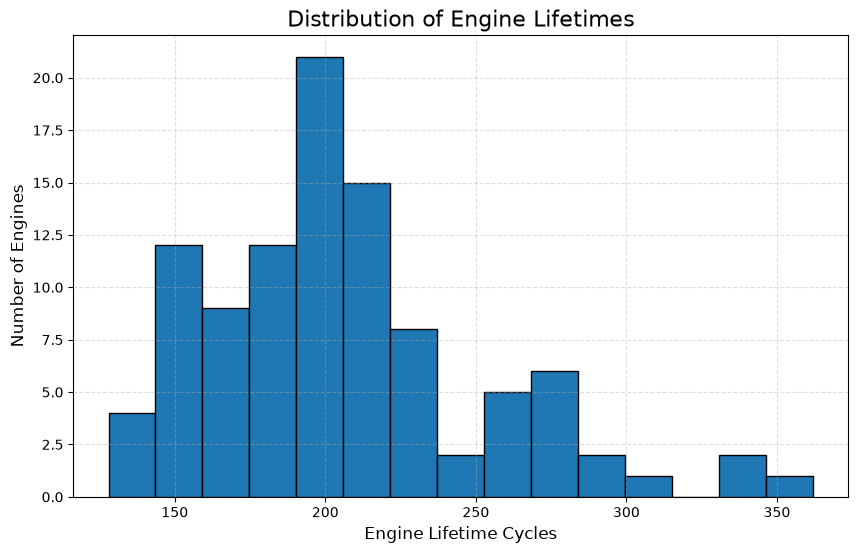

In [5]:

plt.figure(figsize=(10,6))

plt.hist(engine_lifetime, bins=15, edgecolor="black")

plt.title("Distribution of Engine Lifetimes",fontsize=16)
plt.xlabel('Engine Lifetime Cycles',fontsize=12)
plt.ylabel('Number of Engines',fontsize=12)

plt.grid(True, linestyle='--',alpha=0.4)

plt.savefig("../figures/engine_lifetime_histogram.png",dpi=300,bbox_inches="tight")

plt.show()

Observation 1: Most engines reached end of life between 170 and 250 operating cycles, while only a few remained operational after 300 cycles.This indicates that engine lifetimes vary across the fleet rather than occuring at a single fixed cycle.

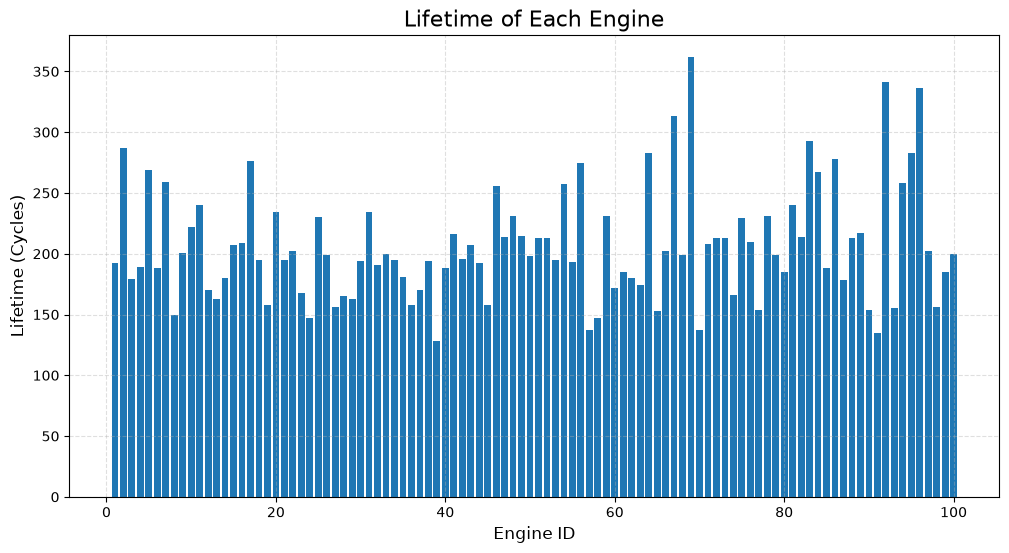

In [6]:

plt.figure(figsize=(12,6))

plt.bar(engine_lifetime.index, engine_lifetime.values)

plt.title("Lifetime of Each Engine", fontsize=16)
plt.xlabel("Engine ID", fontsize=12)
plt.ylabel("Lifetime (Cycles)",fontsize=12)

plt.grid(True, linestyle='--',alpha=0.4)


plt.savefig("../figures/lifetime_of_each_engine_bar.png")

plt.show()

Observation 2: Engine lifetimes show considerable variablility, ranging from 128 to 362 operation cycles. This suggests engines do not deteriorate at the same rate, reinforcing the need for condition-based maintenance instead of maintenance at a fixed operating cycle. 

In [7]:
engine1 = df[df["engine_id"]== 1]

engine1.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


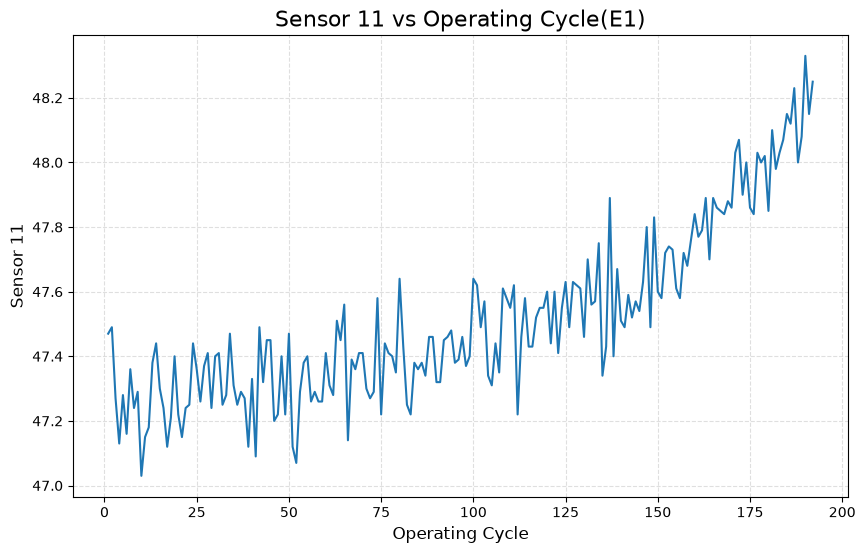

In [8]:

plt.figure(figsize=(10,6))

plt.plot(engine1["cycle"],engine1["sensor_11"])

plt.title("Sensor 11 vs Operating Cycle(E1)",fontsize=16)
plt.xlabel("Operating Cycle",fontsize=12)
plt.ylabel("Sensor 11",fontsize=12)

plt.grid(True,linestyle='--',alpha=0.4)

plt.savefig("../figures/sensor11_vs_operatingcycle(E1).png")

plt.show()

Observation 3: Sensor 11 exhibits an overall increasing trend throughout thte operating cycle of engine 1. Although there is a short term variability,the long term upward trend suggests the sensor may be influenced by engine degradation.

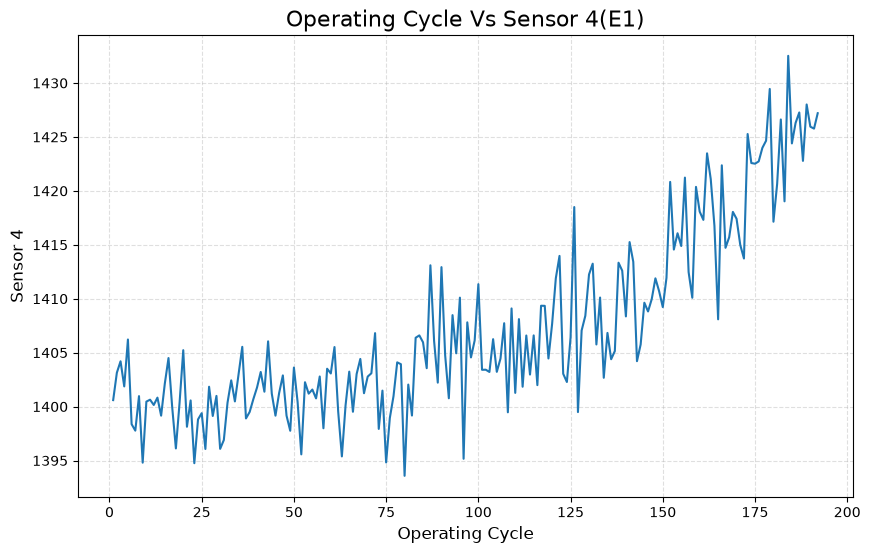

In [9]:

plt.figure(figsize=(10,6))

plt.plot(engine1["cycle"],engine1["sensor_4"])

plt.title('Operating Cycle Vs Sensor 4(E1)',fontsize=16)
plt.xlabel('Operating Cycle',fontsize=12)
plt.ylabel('Sensor 4',fontsize=12)

plt.grid(True,linestyle='--',alpha=0.4)

plt.savefig("../figures/Operating Cycle Vs Sensor 4(E1).png")

plt.show()

Observation 4: Sensor 4 shows a gradual increase throughout the life cycle of Engine 1. The consistent upward trend suggest Sensor 4 may be a useful indicator of the engines life cycle.